In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df = df.dropna(subset=['Description'])

In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,133626
Country,0


In [9]:
df = df[df['Quantity'] > 0]

In [10]:
df['Quantity'].min()

1

In [11]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [12]:
df = df[['InvoiceNo', 'Description', 'Quantity']]

In [13]:
df.head()

,InvoiceNo,Description,Quantity
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,WHITE METAL LANTERN,6
2,536365,CREAM CUPID HEARTS COAT HANGER,8
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6


In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(525259, 3)

In [16]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

top_products.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48375
WHITE HANGING HEART T-LIGHT HOLDER,37871
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36354
RABBIT NIGHT LIGHT,30739


In [17]:
top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

top_products.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48375
WHITE HANGING HEART T-LIGHT HOLDER,37871
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36354
RABBIT NIGHT LIGHT,30739


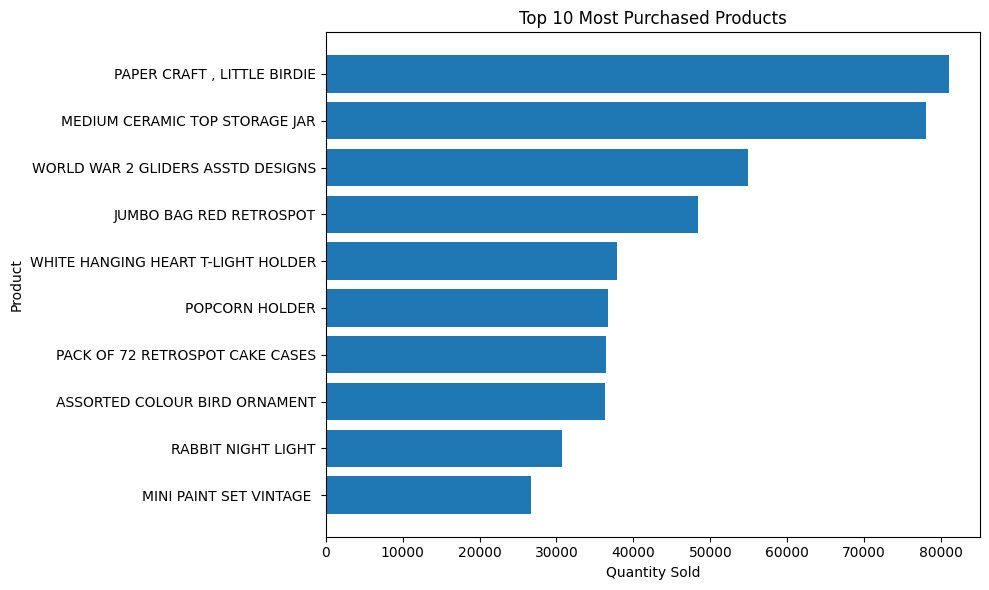

In [18]:
import matplotlib.pyplot as plt

top_10 = top_products.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(top_10.index, top_10.values)

plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Most Purchased Products")

plt.tight_layout()
plt.show()

In [19]:
number_of_transactions = df['InvoiceNo'].nunique()

print("Number of transactions:", number_of_transactions)

Number of transactions: 20136


In [20]:
number_of_products = df['Description'].nunique()

print("Number of different products:", number_of_products)

Number of different products: 4077


In [21]:
total_quantity = df['Quantity'].sum()

print("Total quantity sold:", total_quantity)

Total quantity sold: 5611552


In [22]:
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

basket = basket.map(lambda x: 1 if x > 0 else 0)

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
!pip install mlxtend

In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori

df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

df = df.dropna(subset=['Description'])
df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[['InvoiceNo', 'Description', 'Quantity']]

top_product_names = df.groupby('Description')['Quantity'].sum().nlargest(100).index

df = df[df['Description'].isin(top_product_names)]

basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack(fill_value=0)

basket = (basket > 0).astype('int8')

frequent_itemsets = apriori(
    basket,
    min_support=0.03,
    use_colnames=True,
    max_len=3
)

frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

frequent_itemsets.head(20)

/usr/local/lib/python3.13/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
71,0.147021,(WHITE HANGING HEART T-LIGHT HOLDER)
27,0.136092,(JUMBO BAG RED RETROSPOT)
59,0.129391,(REGENCY CAKESTAND 3 TIER)
51,0.109680,(PARTY BUNTING)
38,0.101743,(LUNCH BAG RED RETROSPOT)
5,0.094653,(ASSORTED COLOUR BIRD ORNAMENT)
47,0.085870,(PACK OF 72 RETROSPOT CAKE CASES)
34,0.082813,(LUNCH BAG BLACK SKULL.)
43,0.081252,(NATURAL SLATE HEART CHALKBOARD )
25,0.079235,(JUMBO BAG PINK POLKADOT)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

rules = rules.sort_values(
    by='lift',
    ascending=False
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
26,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.034999,0.632941,10.810635
27,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.034999,0.597778,10.810635
41,(CHARLOTTE BAG PINK POLKADOT),(RED RETROSPOT CHARLOTTE BAG),0.033958,0.702557,10.444593
40,(RED RETROSPOT CHARLOTTE BAG),(CHARLOTTE BAG PINK POLKADOT),0.033958,0.504836,10.444593
61,(RED RETROSPOT CHARLOTTE BAG),(STRAWBERRY CHARLOTTE BAG),0.031616,0.470019,10.007115
60,(STRAWBERRY CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.031616,0.673130,10.007115
52,(WOODLAND CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.032917,0.605988,9.008944
53,(RED RETROSPOT CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.032917,0.489362,9.008944
21,(PAPER CHAIN KIT 50'S CHRISTMAS ),(PAPER CHAIN KIT VINTAGE CHRISTMAS),0.035909,0.475862,8.920673
20,(PAPER CHAIN KIT VINTAGE CHRISTMAS),(PAPER CHAIN KIT 50'S CHRISTMAS ),0.035909,0.673171,8.920673


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
strong_rules = rules[
    (rules['confidence'] >= 0.5) &
    (rules['lift'] > 1)
]

strong_rules = strong_rules.sort_values(
    by='lift',
    ascending=False
)

strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
26,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.034999,0.632941,10.810635
27,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.034999,0.597778,10.810635
41,(CHARLOTTE BAG PINK POLKADOT),(RED RETROSPOT CHARLOTTE BAG),0.033958,0.702557,10.444593
40,(RED RETROSPOT CHARLOTTE BAG),(CHARLOTTE BAG PINK POLKADOT),0.033958,0.504836,10.444593
60,(STRAWBERRY CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.031616,0.673130,10.007115
52,(WOODLAND CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.032917,0.605988,9.008944
20,(PAPER CHAIN KIT VINTAGE CHRISTMAS),(PAPER CHAIN KIT 50'S CHRISTMAS ),0.035909,0.673171,8.920673
51,(CHARLOTTE BAG SUKI DESIGN),(RED RETROSPOT CHARLOTTE BAG),0.032982,0.574830,8.545731
57,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.032071,0.532397,6.814332
9,(LUNCH BAG PINK POLKADOT),(LUNCH BAG RED RETROSPOT),0.039422,0.555963,5.464366


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
strong_rules['antecedents'] = strong_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
strong_rules['consequents'] = strong_rules['consequents'].apply(lambda x: ', '.join(list(x)))

strong_rules['Rule'] = strong_rules['antecedents'] + ' → ' + strong_rules['consequents']

strong_rules[['Rule', 'support', 'confidence', 'lift']].head(20)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Rule,support,confidence,lift
26,DOLLY GIRL LUNCH BOX → SPACEBOY LUNCH BOX,0.034999,0.632941,10.810635
27,SPACEBOY LUNCH BOX → DOLLY GIRL LUNCH BOX,0.034999,0.597778,10.810635
41,CHARLOTTE BAG PINK POLKADOT → RED RETROSPOT CH...,0.033958,0.702557,10.444593
40,RED RETROSPOT CHARLOTTE BAG → CHARLOTTE BAG PI...,0.033958,0.504836,10.444593
60,STRAWBERRY CHARLOTTE BAG → RED RETROSPOT CHARL...,0.031616,0.673130,10.007115
52,WOODLAND CHARLOTTE BAG → RED RETROSPOT CHARLOT...,0.032917,0.605988,9.008944
20,PAPER CHAIN KIT VINTAGE CHRISTMAS → PAPER CHAI...,0.035909,0.673171,8.920673
51,CHARLOTTE BAG SUKI DESIGN → RED RETROSPOT CHAR...,0.032982,0.574830,8.545731
57,HEART OF WICKER LARGE → HEART OF WICKER SMALL,0.032071,0.532397,6.814332
9,LUNCH BAG PINK POLKADOT → LUNCH BAG RED RETROSPOT,0.039422,0.555963,5.464366


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

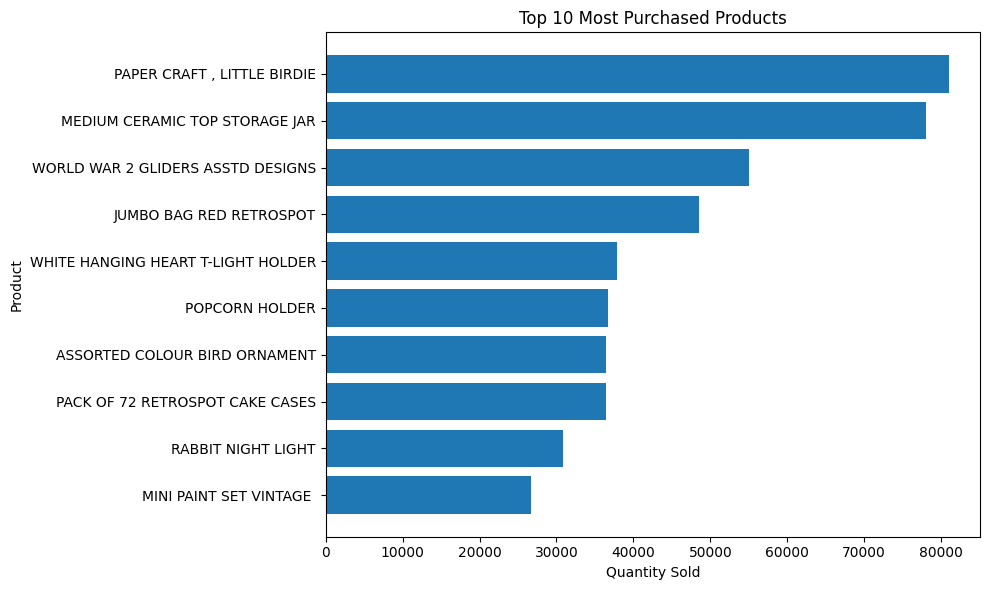

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [5]:
import matplotlib.pyplot as plt

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_products.index, top_products.values)
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.title('Top 10 Most Purchased Products')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

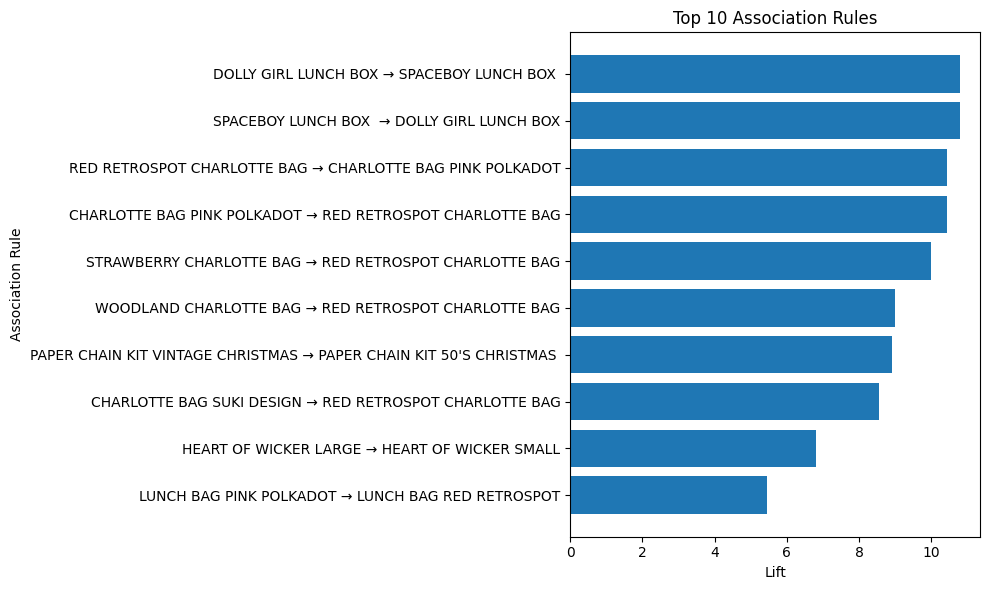

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [6]:
top_rules = strong_rules.head(10).sort_values('lift')

plt.figure(figsize=(10, 6))
plt.barh(top_rules['Rule'], top_rules['lift'])
plt.xlabel('Lift')
plt.ylabel('Association Rule')
plt.title('Top 10 Association Rules')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

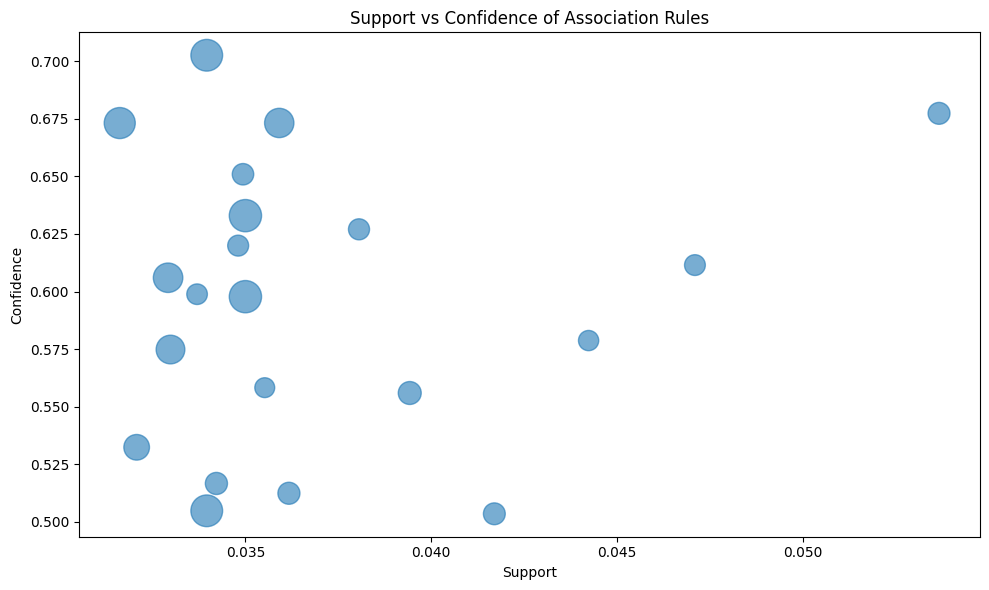

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(
    strong_rules['support'],
    strong_rules['confidence'],
    s=strong_rules['lift'] * 50,
    alpha=0.6
)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence of Association Rules')
plt.tight_layout()
plt.show()

In [8]:
top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()

top_rules['antecedents'] = top_rules['antecedents'].apply(
    lambda x: ', '.join(x)
)

top_rules['consequents'] = top_rules['consequents'].apply(
    lambda x: ', '.join(x)
)

top_rules = top_rules.sort_values(
    by='lift',
    ascending=False
).head(10)

top_rules

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
26,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.034999,0.632941,10.810635
27,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.034999,0.597778,10.810635
41,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,0.033958,0.702557,10.444593
40,RED RETROSPOT CHARLOTTE BAG,CHARLOTTE BAG PINK POLKADOT,0.033958,0.504836,10.444593
61,RED RETROSPOT CHARLOTTE BAG,STRAWBERRY CHARLOTTE BAG,0.031616,0.470019,10.007115
60,STRAWBERRY CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,0.031616,0.673130,10.007115
52,WOODLAND CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,0.032917,0.605988,9.008944
53,RED RETROSPOT CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,0.032917,0.489362,9.008944
21,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,0.035909,0.475862,8.920673
20,PAPER CHAIN KIT VINTAGE CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,0.035909,0.673171,8.920673


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

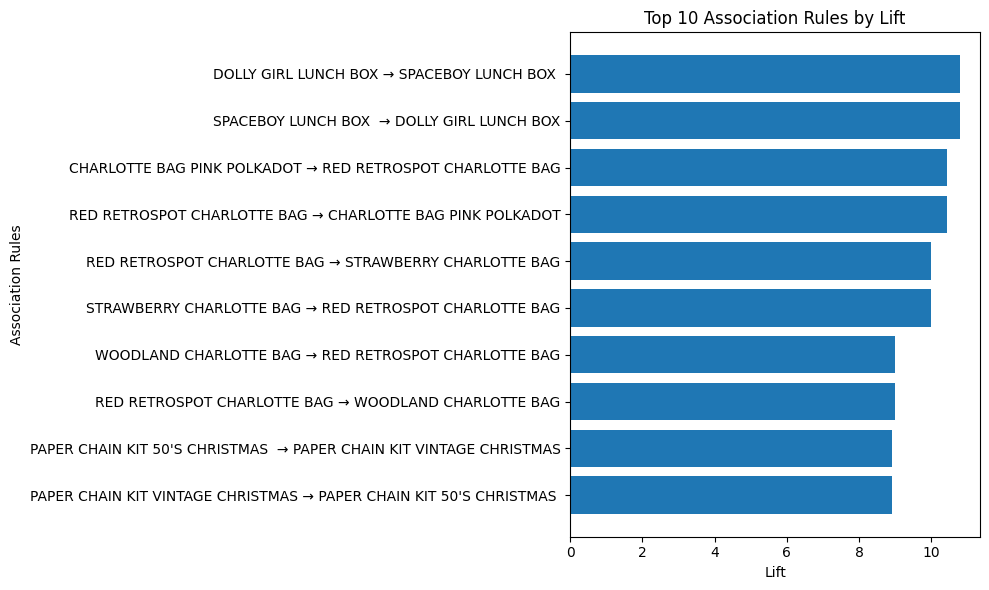

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_rules['antecedents'] + ' → ' + top_rules['consequents'],
    top_rules['lift']
)

plt.xlabel('Lift')
plt.ylabel('Association Rules')
plt.title('Top 10 Association Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [10]:
business_insights = []

for _, row in top_rules.iterrows():
    antecedent = row['antecedents']
    consequent = row['consequents']
    confidence = row['confidence']
    lift = row['lift']

    if lift > 1:
        insight = (
            f"Customers purchasing {antecedent} also show a positive "
            f"association with {consequent}. This relationship can be "
            f"considered for cross-selling and product recommendations."
        )
    elif lift == 1:
        insight = (
            f"{antecedent} and {consequent} show no significant additional "
            f"association beyond what would be expected by chance."
        )
    else:
        insight = (
            f"{antecedent} and {consequent} show a negative association, "
            f"so this relationship may be less useful for cross-selling."
        )

    business_insights.append({
        'Product Combination': f"{antecedent} → {consequent}",
        'Confidence': confidence,
        'Lift': lift,
        'Business Insight': insight
    })

business_insights

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

[{'Product Combination': 'DOLLY GIRL LUNCH BOX → SPACEBOY LUNCH BOX ',
  'Confidence': 0.6329411764705882,
  'Lift': 10.810635294117647,
  'Business Insight': 'Customers purchasing DOLLY GIRL LUNCH BOX also show a positive association with SPACEBOY LUNCH BOX . This relationship can be considered for cross-selling and product recommendations.'},
 {'Product Combination': 'SPACEBOY LUNCH BOX  → DOLLY GIRL LUNCH BOX',
  'Confidence': 0.5977777777777777,
  'Lift': 10.810635294117645,
  'Business Insight': 'Customers purchasing SPACEBOY LUNCH BOX  also show a positive association with DOLLY GIRL LUNCH BOX. This relationship can be considered for cross-selling and product recommendations.'},
 {'Product Combination': 'CHARLOTTE BAG PINK POLKADOT → RED RETROSPOT CHARLOTTE BAG',
  'Confidence': 0.702557200538358,
  'Lift': 10.444593120576053,
  'Business Insight': 'Customers purchasing CHARLOTTE BAG PINK POLKADOT also show a positive association with RED RETROSPOT CHARLOTTE BAG. This relationshi

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 15. Conclusion

Market Basket Analysis was successfully performed on retail transaction data using the Apriori algorithm. The analysis identified frequently purchased products and meaningful relationships between products using support, confidence, and lift.

The results showed strong associations among several products, including lunch boxes, Charlotte bags, and Christmas paper chain kits. These purchasing patterns can help businesses improve product recommendations, cross-selling strategies, promotional offers, store layout, and inventory planning.

Overall, the project demonstrates how data mining techniques can be used to discover hidden relationships in retail transaction data and generate useful business insights for better decision-making.